# Pain Prediction Analysis - Synthetic 200p Dataset
**Dataset**: `../../pain_dataset_200P_4hz.csv`

This notebook implements the machine learning pipeline for pain scale prediction:
1. **EDA**: Visualizing distributions and correlations.
2. **Feature Engineering**: Vector magnitudes, stress index, and temp variations.
3. **Model Training**: Decision Tree for pain scale prediction.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Load the dataset
df = pd.read_csv('../../pain_dataset_200P_4hz.csv')
df= df.iloc[:86400]

# Ignore person_ID as it is unnecessary for the model
if 'person_ID' in df.columns:
    df = df.drop(columns=['person_ID'])

print(f"Dataset Loaded: {df.shape[0]} samples, {df.shape[1]} features.")
display(df.head())


Dataset Loaded: 86400 samples, 8 features.


,acc_x,acc_y,acc_z,eda,bvp,hr,temp,pain_scale
0,0.2751,-0.0464,0.3049,0.7395,99.24,67.6,33.94,5
1,0.2428,-0.1161,0.3641,0.7793,103.24,68.3,33.95,5
2,0.0146,-0.1479,0.6552,0.8581,103.08,68.1,33.91,5
3,-0.0806,-0.2144,0.6631,0.8881,104.12,66.6,33.94,5
4,-0.0808,-0.1754,0.5448,0.7786,107.05,66.8,33.95,5


## 1. Exploratory Data Analysis (EDA)

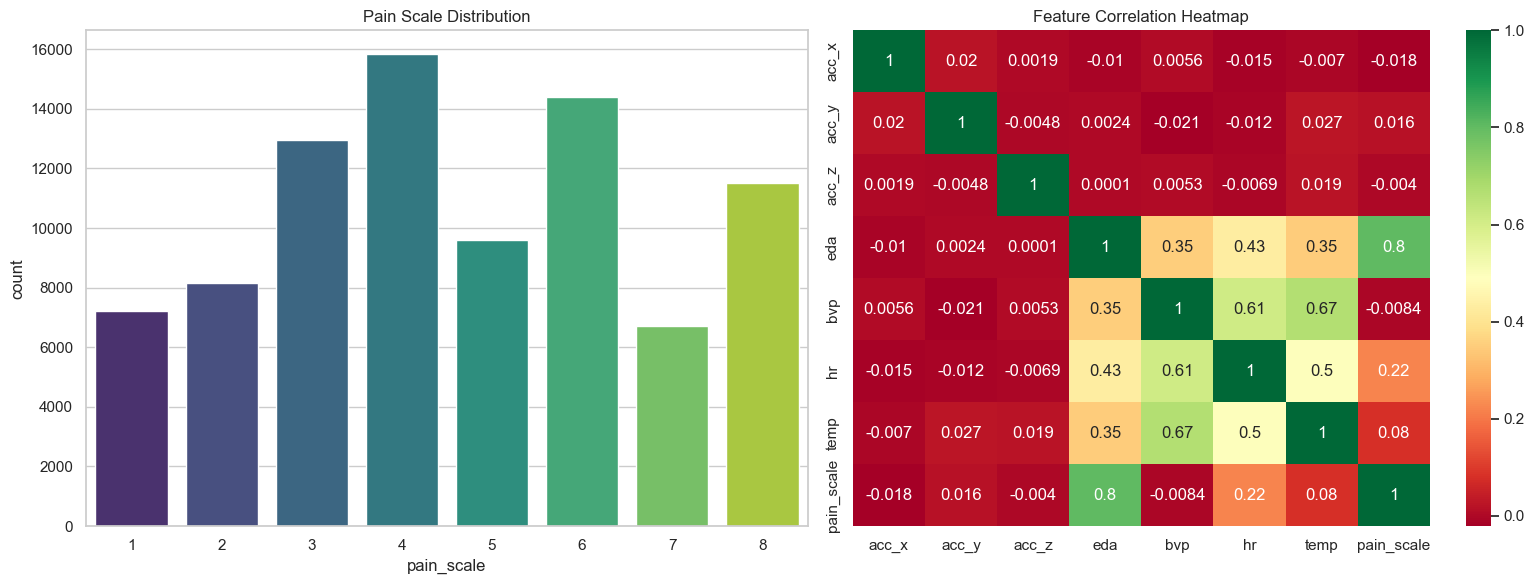

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Pain Scale Distribution
target_col = 'pain_scale'
sns.countplot(data=df, x=target_col, palette='viridis', ax=ax[0])
ax[0].set_title('Pain Scale Distribution')

# Correlation Matrix
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', ax=ax[1])
ax[1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

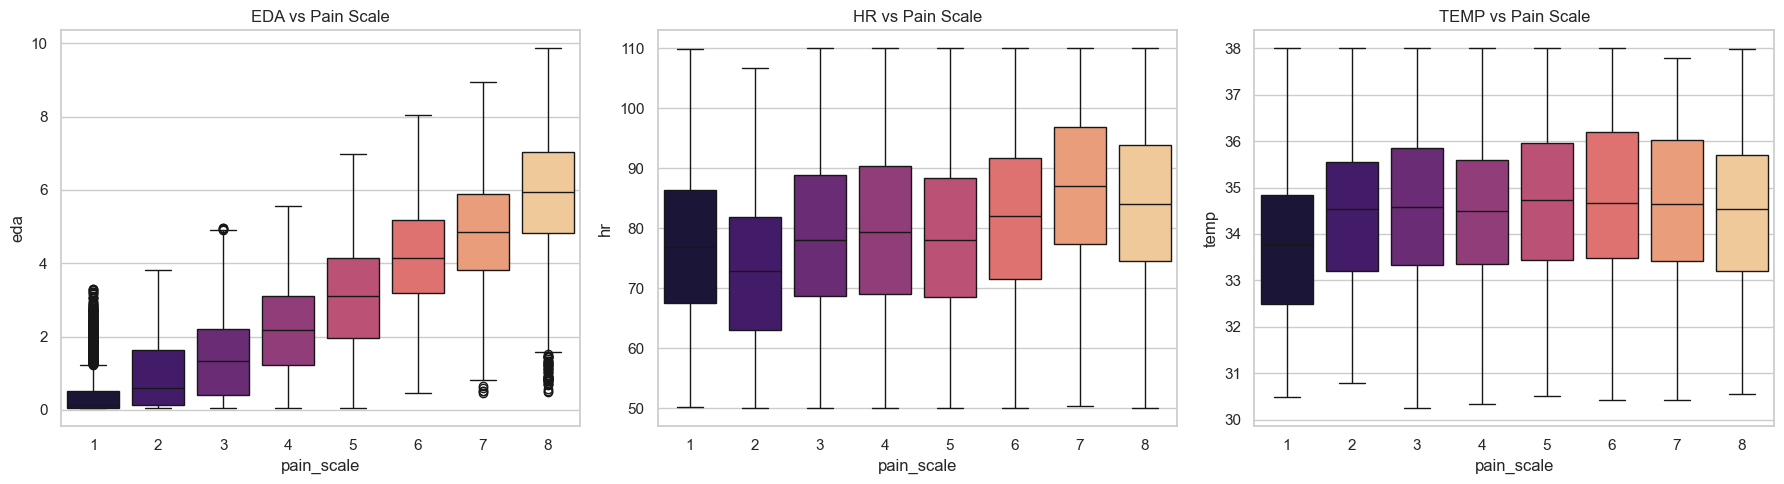

In [43]:
# Boxplots of key features by Pain Scale
features_to_plot = ['eda', 'hr', 'temp']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, feat in enumerate(features_to_plot):
    sns.boxplot(data=df, x='pain_scale', y=feat, ax=axes[i], palette='magma')
    axes[i].set_title(f'{feat.upper()} vs Pain Scale')

plt.tight_layout()
plt.show()

## 2. Feature Engineering

In [44]:
def engineer_features(data):
    df_fe = data.copy()
    
    # 1. Acceleration Magnitude (Movement State)
    df_fe['acc_magnitude'] = np.sqrt(df_fe['acc_x']**2 + df_fe['acc_y']**2 + df_fe['acc_z']**2)
    
    # 2. Stress Index interaction (EDA * HR)
    df_fe['stress_index'] = df_fe['eda'] * df_fe['hr']
    
    # 3. Temp Delta (Variation from mean Body Temp)
    df_fe['temp_delta'] = np.abs(df_fe['temp'] - df_fe['temp'].mean())
    
    return df_fe

print("Performing advanced feature engineering...")
df_proc = engineer_features(df)
print(f"Feature space expanded: {df_proc.shape[1]} columns.")

Performing advanced feature engineering...
Feature space expanded: 11 columns.


## 3. Machine Learning: Decision Tree


In [45]:
X = df_proc.drop(columns=['pain_scale'])
y = df_proc['pain_scale']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training Decision Tree classifier...")
decision_tree_model = DecisionTreeClassifier(max_depth=18, min_samples_split=4, random_state=42)
decision_tree_model.fit(X_train_scaled, y_train)

y_preds = decision_tree_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_preds)

print(f"\nSystem Validation Accuracy: {accuracy*100:.2f}%")


Training Decision Tree classifier...

System Validation Accuracy: 69.47%


## 4. Save the Model


In [46]:
# Save the trained model and scaler for future inference
model_filename = 'pain_prediction_model_decision_tree.joblib'
joblib.dump({'model': decision_tree_model, 'scaler': scaler}, model_filename)
print(f"Model and Scaler saved successfully to {model_filename}")


Model and Scaler saved successfully to pain_prediction_model_decision_tree.joblib


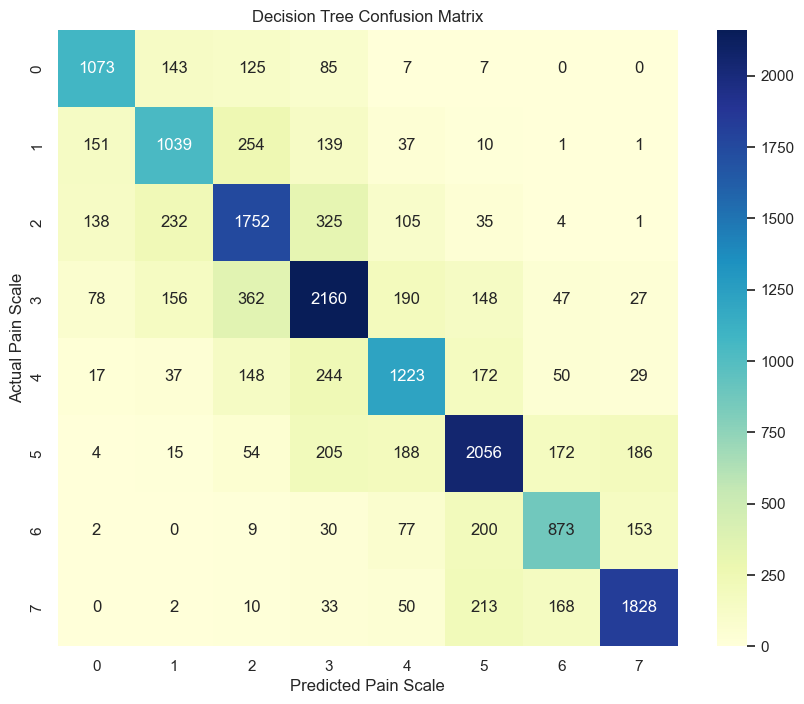

Full Metrics Report:
              precision    recall  f1-score   support

           1       0.73      0.75      0.74      1440
           2       0.64      0.64      0.64      1632
           3       0.65      0.68      0.66      2592
           4       0.67      0.68      0.68      3168
           5       0.65      0.64      0.64      1920
           6       0.72      0.71      0.72      2880
           7       0.66      0.65      0.66      1344
           8       0.82      0.79      0.81      2304

    accuracy                           0.69     17280
   macro avg       0.69      0.69      0.69     17280
weighted avg       0.70      0.69      0.69     17280



In [47]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Decision Tree Confusion Matrix')
plt.ylabel('Actual Pain Scale')
plt.xlabel('Predicted Pain Scale')
plt.show()

print("Full Metrics Report:")
print(classification_report(y_test, y_preds))


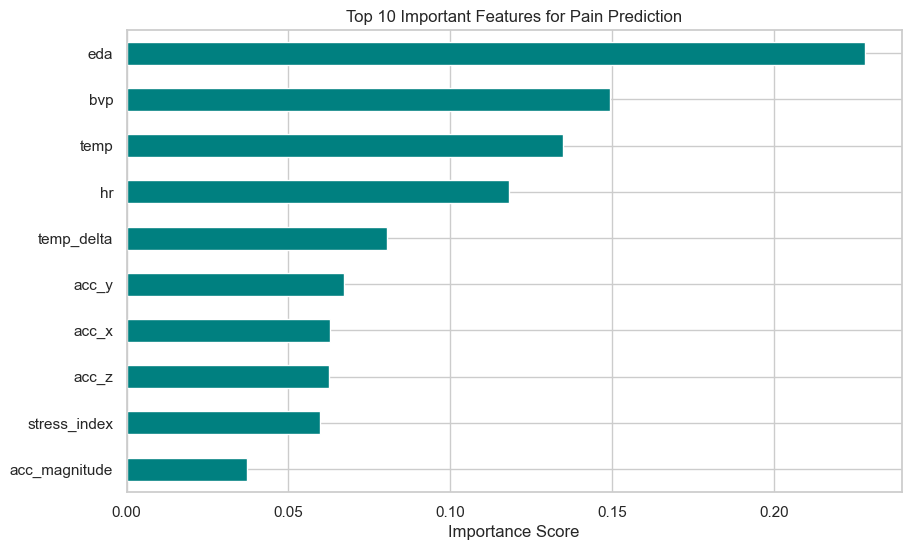

In [48]:
feat_importances = pd.Series(decision_tree_model.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 Important Features for Pain Prediction')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

## 5. Segment Inference (Time Series)
Logic to process 280-row segments and return average prediction.

In [49]:
def predict_and_average_segment(segment_df, trained_model, trained_scaler):
    """
    Processes a 280-row segment of data, performs feature engineering, 
    and returns the average pain scale prediction.
    """
    # 1. Feature Engineering
    df_proc = engineer_features(segment_df)
    
    # 2. Drop unnecessary columns if they exist (except features expected by model)
    if 'person_ID' in df_proc.columns:
        df_proc = df_proc.drop(columns=['person_ID'])
    if 'pain_scale' in df_proc.columns:
        df_proc = df_proc.drop(columns=['pain_scale'])
        
    # 3. Scaling
    X_scaled = trained_scaler.transform(df_proc)
    
    # 4. Prediction
    predictions = trained_model.predict(X_scaled)
    
    # 5. Average
    avg_prediction = np.mean(predictions)
    
    return avg_prediction


In [ ]:
input= pd.read_csv("..\..\person_data\P174.csv")

avg_pain = predict_and_average_segment(input, decision_tree_model, scaler)
print(f"Average Pain Scale for segment: {avg_pain:.2f}")
actual_score_first = input['pain_scale'].iloc[0]
print(f"Actual Pain Scale for segment: {actual_score_first:.2f}")

Average Pain Scale for segment: 5.98
